In [37]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def extract_data(filedir):
    files = os.listdir(filedir)
    df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
    df_list = [df.drop(0) for df in df_list]
    df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
    data = pd.concat(df_list, ignore_index=True)    
    return data


dir1 = "F:/IMU_computational_ethology/Data/LSD/5d"
dir2 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_e8"


data1 = extract_data(dir1)
data2 = extract_data(dir2)

print(data1.shape)
print(data2.shape)

def time_transform(arr):

    arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
    secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
    return secs

time_onchip1 = time_transform([x.split(" ", 2)[2] for x in data1[2]])
time_onchip2 = time_transform([x.split(" ", 2)[2] for x in data2[2]])


time_sys1 = time_transform(data1[0])
time_sys2 = time_transform(data2[0])

#测试掉帧
t1 = time_onchip1
t2 = time_onchip2


def frameloss_test(t):
    fl_count = 0
    lostframes = 0 
    for i in range(1, len(t)):
        if float(t[i]) - float(t[i-1]) >= 0.02:
            fl_count += 1
            lostframes += int((t[i] - t[i-1]) / 0.01) - 1
            #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
    print(f"frame loss count: {fl_count}")
    print(f"total lost frames: {lostframes}")

frameloss_test(t1)
frameloss_test(t2)


import numpy as np
from scipy.interpolate import PchipInterpolator
def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1.values)
t_new2, sig2, sig_ori2, fs2, drift2, t_est2 = align_imu(data2.values)
t_new1 = t_new1-t_new1[0]
t_new2 = t_new2-t_new2[0]


ta = t_new1 - 6.6
tb = t_new2 - 6.6

ta_p = ta[ta >= 0]
imu_a = sig1[-len(ta_p):]
tb_p = tb[tb >= 0]
imu_b = sig2[-len(tb_p):]

(359064, 15)
(460404, 15)
frame loss count: 6
total lost frames: 28
frame loss count: 335
total lost frames: 2699


In [1]:
import numpy as np

def extract_segment(
    start_time: float,
    end_time: float,
    data: np.ndarray,
    timestamps: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:

    # 布尔掩码：选择 [start_time, end_time] 范围内的所有采样点
    mask = (timestamps >= start_time) & (timestamps <= end_time)
    
    seg_data = data[mask]
    seg_timestamps = timestamps[mask]
    
    return seg_data, seg_timestamps


seg_data, seg_time = extract_segment(60, 660, imu_a, ta_p)

print(seg_time.shape)   # (1279,)  约 14.8秒的数据
print(seg_data.shape)   # (1279, 6)

NameError: name 'imu_a' is not defined

In [39]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

def select_optimal_gmm_clusters(z, max_clusters=15, criterion='bic', plot=True):
    """
    通过 BIC/AIC 自动选择最优 GMM 聚类数
    
    参数:
        z: (N, latent_dim) 潜在向量
        max_clusters: 最大搜索的聚类数
        criterion: 'bic' 或 'aic'
        plot: 是否绘制 BIC/AIC 曲线
    
    返回:
        optimal_n: 最优聚类数
        best_model: 拟合好的最优 GMM 模型
        labels: 最优模型预测的类别标签
    """
    n_samples, n_features = z.shape
    max_clusters = min(max_clusters, n_samples // 10)  # 避免样本数不足
    
    scores = []
    models = []
    n_range = range(2, max_clusters + 1)
    
    for n in n_range:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type='full',      # 每个高斯有完整的协方差矩阵
            random_state=42,
            max_iter=200,
            n_init=5                     # 多次随机初始化，避免局部最优
        )
        gmm.fit(z)
        
        if criterion == 'bic':
            score = gmm.bic(z)
        else:
            score = gmm.aic(z)
        
        scores.append(score)
        models.append(gmm)
        print(f"  n_clusters={n:2d}, {criterion.upper()}={score:.2f}")
    
    # 选择分数最低的（BIC/AIC 越小越好）
    optimal_idx = np.argmin(scores)
    optimal_n = list(n_range)[optimal_idx]
    best_model = models[optimal_idx]
    labels = best_model.predict(z)
    
    print(f"\n最优聚类数: {optimal_n} ({criterion.upper()}={scores[optimal_idx]:.2f})")
    
    # 可选: 绘制 BIC/AIC 曲线
    if plot:
        plt.figure(figsize=(8, 4))
        plt.plot(list(n_range), scores, 'bo-', linewidth=1.5, markersize=6)
        plt.axvline(optimal_n, color='r', linestyle='--', 
                   label=f'Optimal: {optimal_n}')
        plt.xlabel('Number of Clusters')
        plt.ylabel(criterion.upper())
        plt.title(f'GMM {criterion.upper()} Score vs. Number of Clusters')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    
    return optimal_n, best_model, labels

In [40]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.signal import medfilt
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

class Config:
    SAMPLING_RATE = fs1
    WINDOW_SIZE = 100          # 1.0秒窗口，更细粒度
    STRIDE = 25                # 0.25秒步长，更密采样
    
    INPUT_DIM = 6
    HIDDEN_DIM = 256           # 更大容量
    NUM_GRU_LAYERS = 3
    LATENT_DIM = 32            # 更多潜在维度
    BIDIRECTIONAL = True
    DROPOUT = 0.3
    
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-3
    EPOCHS = 100
    BETA_KL = 0.0001           # 关键：大幅降低，保留行为细节
    PATIENCE = 10
    
               # 更多类别
    CLUSTER_METHOD = 'GMM'   # 自动发现类别，避免人为限制
    
    MEDIAN_FILTER_WIN = 5      

In [42]:
# ==================== 数据预处理 ====================
def create_sliding_windows(
    data: np.ndarray,
    timestamps: np.ndarray,
    config: Config
) -> Tuple[np.ndarray, np.ndarray]:
    """
    滑动窗口切分
    输入: data (n, 6), timestamps (n,)
    返回: (windows [N x W x 6], window_center_times [N])
    """
    T, C = data.shape
    W, S = config.WINDOW_SIZE, config.STRIDE

    windows = []
    center_times = []

    for start in range(0, T - W + 1, S):
        end = start + W
        windows.append(data[start:end])
        # 窗口中心对应的时间戳
        center_times.append(timestamps[start + W // 2])

    return np.array(windows), np.array(center_times)


# ==================== GRU-VAE 模型 ====================
class GRUEncoder(nn.Module):
    """GRU 编码器: 将 IMU 窗口压缩为潜在向量 z"""
    def __init__(self, config: Config):
        super().__init__()
        self.input_dim = config.INPUT_DIM
        self.hidden_dim = config.HIDDEN_DIM
        self.latent_dim = config.LATENT_DIM
        self.num_layers = config.NUM_GRU_LAYERS
        self.bidirectional = config.BIDIRECTIONAL

        # 双向GRU: 输出维度 = hidden_dim * 2
        self.gru = nn.GRU(
            input_size=self.input_dim,
            hidden_size=self.hidden_dim,
            num_layers=self.num_layers,
            batch_first=True,
            bidirectional=self.bidirectional,
            dropout=config.DROPOUT if self.num_layers > 1 else 0
        )

        gru_out_dim = self.hidden_dim * (2 if self.bidirectional else 1)

        # 输出潜在空间的均值和对数方差
        self.fc_mu = nn.Linear(gru_out_dim, self.latent_dim)
        self.fc_logvar = nn.Linear(gru_out_dim, self.latent_dim)

    def forward(self, x):
        # x: [batch, window_size, 6]
        _, h_n = self.gru(x)  # h_n: [num_layers*directions, batch, hidden_dim]

        # 取最后一层的最终隐藏状态
        if self.bidirectional:
            # 拼接前向和后向的最后状态
            h_last = torch.cat((h_n[-2], h_n[-1]), dim=-1)  # [batch, hidden_dim*2]
        else:
            h_last = h_n[-1]  # [batch, hidden_dim]

        mu = self.fc_mu(h_last)
        logvar = self.fc_logvar(h_last)
        return mu, logvar


class GRUDecoder(nn.Module):
    """GRU 解码器: 从潜在向量 z 重构 IMU 窗口"""
    def __init__(self, config: Config):
        super().__init__()
        self.latent_dim = config.LATENT_DIM
        self.hidden_dim = config.HIDDEN_DIM
        self.num_layers = config.NUM_GRU_LAYERS
        self.bidirectional = config.BIDIRECTIONAL

        # 将 z 映射为初始隐藏状态
        gru_out_dim = self.hidden_dim * (2 if self.bidirectional else 1)
        self.fc_init = nn.Linear(self.latent_dim, self.hidden_dim)

        self.gru = nn.GRU(
            input_size=self.latent_dim,  # 每一步输入 z
            hidden_size=self.hidden_dim,
            num_layers=self.num_layers,
            batch_first=True,
            bidirectional=self.bidirectional,
            dropout=config.DROPOUT if self.num_layers > 1 else 0
        )

        self.fc_out = nn.Linear(gru_out_dim, config.INPUT_DIM)

    def forward(self, z, window_size):
        # z: [batch, latent_dim]
        # 初始化隐藏状态
        h0 = self.fc_init(z).unsqueeze(0)  # [1, batch, hidden_dim*directions]
        if self.bidirectional:
            h0 = h0.repeat(self.num_layers * 2, 1, 1)
        else:
            h0 = h0.repeat(self.num_layers, 1, 1)

        # 将 z 重复为 [batch, window_size, latent_dim]
        z_input = z.unsqueeze(1).repeat(1, window_size, 1)

        out, _ = self.gru(z_input, h0)  # [batch, window_size, hidden_dim*directions]
        recon = self.fc_out(out)         # [batch, window_size, 6]
        return recon


class GRUVAE(nn.Module):
    def __init__(self, config: Config):
        super().__init__()
        self.encoder = GRUEncoder(config)
        self.decoder = GRUDecoder(config)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z, x.size(1))
        return recon, mu, logvar



In [43]:
from typing import Dict, Any
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt
from collections import defaultdict



def vae_loss(recon, original, mu, logvar, beta):
    recon_loss = nn.MSELoss(reduction='sum')(recon, original) / original.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / original.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss
# ==================== 训练函数（增加返回训练历史）====================
def train_model(model, train_loader, val_loader, config, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = defaultdict(list)  # 新增：记录训练历史
    
    for epoch in range(config.EPOCHS):
        # --- 训练 ---
        model.train()
        epoch_recon, epoch_kl, epoch_total = 0, 0, 0
        
        for batch in train_loader:
            x = batch[0].to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, config.BETA_KL)
            loss.backward()
            optimizer.step()
            
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()
            epoch_total += loss.item()
        
        # --- 验证 ---
        model.eval()
        val_recon, val_kl, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device)
                recon, mu, logvar = model(x)
                loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, config.BETA_KL)
                val_recon += recon_loss.item()
                val_kl += kl_loss.item()
                val_total += loss.item()
        
        n_train = len(train_loader)
        n_val = len(val_loader) if len(val_loader) > 0 else 1
        
        # 记录历史
        history['epoch'].append(epoch)
        history['train_recon'].append(epoch_recon / n_train)
        history['train_kl'].append(epoch_kl / n_train)
        history['train_total'].append(epoch_total / n_train)
        history['val_recon'].append(val_recon / n_val)
        history['val_kl'].append(val_kl / n_val)
        history['val_total'].append(val_total / n_val)
        
        val_loss = val_total / n_val
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_gru_vae.pt')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config.EPOCHS}, "
                  f"Train: recon={epoch_recon/n_train:.4f} kl={epoch_kl/n_train:.4f}, "
                  f"Val: total={val_loss:.4f}")
        
        if patience_counter >= config.PATIENCE:
            print(f"早停于 Epoch {epoch+1}")
            break
    
    return dict(history)  # 返回训练历史


# ==================== 主函数（增加返回中间变量）====================
def segment_behavior(
    timestamps: np.ndarray,
    imu_data: np.ndarray,
    config: Config = None
) -> tuple[
    pd.DataFrame,      # segments_df: 行为片段
    nn.Module,         # model: 训练好的模型
    StandardScaler,    # scaler: 标准化器
    dict               # intermediates: 中间变量字典
]:
    """
    主函数: 输入时间戳和IMU数据, 输出行为片段及中间变量
    
    返回:
        segments_df:  行为片段 DataFrame
        model:        训练好的 GRUVAE
        scaler:       StandardScaler
        intermediates: 字典，包含:
            - 'z': (N, latent_dim) 潜在空间向量
            - 'labels': (N,) 窗口级聚类标签
            - 'win_center_times': (N,) 窗口中心时间戳
            - 'windows': (N, W, 6) 滑动窗口数据
            - 'norm_data': (T, 6) 标准化后的原始数据
            - 'time_labels': (T,) 每个时间点的行为标签
            - 'train_history': dict 训练损失历史
            - 'vote_counts': (T, n_classes) 投票矩阵
    """
    if config is None:
        config = Config()

    assert timestamps.ndim == 1
    assert imu_data.ndim == 2 and imu_data.shape[1] == 6
    assert len(timestamps) == len(imu_data)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 标准化
    scaler = StandardScaler()
    norm_data = scaler.fit_transform(imu_data)
    T = len(timestamps)

    # 2. 滑动窗口
    windows, win_center_times = create_sliding_windows(norm_data, timestamps, config)
    N, W, C = windows.shape
    print(f"生成 {N} 个窗口, 每个窗口 {W} 点 ({W / config.SAMPLING_RATE:.2f}秒)")

    # 3. 划分数据集
    split_idx = int(N * 0.8)
    train_data = torch.FloatTensor(windows[:split_idx])
    val_data = torch.FloatTensor(windows[split_idx:])

    train_loader = DataLoader(TensorDataset(train_data), batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(val_data), batch_size=config.BATCH_SIZE)

    # 4. 训练
    model = GRUVAE(config).to(device)
    print("开始训练 GRU-VAE...")
    train_history = train_model(model, train_loader, val_loader, config, device)

    # 5. 分批编码到潜在空间
    model.load_state_dict(torch.load('best_gru_vae.pt'))
    model.eval()

    encode_loader = DataLoader(
        TensorDataset(torch.FloatTensor(windows)),
        batch_size=config.BATCH_SIZE,
        shuffle=False
    )

    z_list = []
    with torch.no_grad():
        for batch in encode_loader:
            x = batch[0].to(device)
            mu, _ = model.encoder(x)
            z_list.append(mu.cpu())

    z = torch.cat(z_list, dim=0).numpy()  # (N, latent_dim)

    # 6. 聚类
    if config.CLUSTER_METHOD == 'GMM':
        optimal_n, best_model, labels = select_optimal_gmm_clusters(
            z, max_clusters=20, criterion='bic', plot=True
        )
    else:
        try:
            import hdbscan
            clusterer = hdbscan.HDBSCAN(
                min_cluster_size=max(10, N // 20), min_samples=5
            )
            labels = clusterer.fit_predict(z)
        except ImportError:
            print("HDBSCAN 未安装, 回退到 GMM")
            optimal_n, best_model, labels = select_optimal_gmm_clusters(
                z, max_clusters=12, criterion='bic', plot=True
            )

    n_behaviors = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"发现 {n_behaviors} 个行为类别")

    # 7. 窗口标签映射回时间轴
    max_label = int(np.max(labels))
    time_labels = np.full(T, -1, dtype=int)
    vote_counts = np.zeros((T, max_label + 1), dtype=int)

    for i, (start, label) in enumerate(zip(range(0, T - W + 1, config.STRIDE), labels)):
        end = start + W
        if label >= 0:
            vote_counts[start:end, label] += 1

    vote_sums = vote_counts.sum(axis=1)
    valid_mask = vote_sums > 0
    time_labels[valid_mask] = np.argmax(vote_counts[valid_mask], axis=1)

    # 填充首尾
    if not valid_mask[0]:
        first_valid = np.where(valid_mask)[0][0]
        time_labels[:first_valid] = time_labels[first_valid]
    if not valid_mask[-1]:
        last_valid = np.where(valid_mask)[0][-1]
        time_labels[last_valid + 1:] = time_labels[last_valid]

    # 8. 中值滤波
    if config.MEDIAN_FILTER_WIN > 1:
        time_labels = medfilt(time_labels, kernel_size=config.MEDIAN_FILTER_WIN).astype(int)

    # 9. 提取连续片段
    segments = []
    start_idx = 0
    current_label = time_labels[0]

    for i in range(1, T):
        if time_labels[i] != current_label:
            segments.append({
                'start_time': float(timestamps[start_idx]),
                'end_time': float(timestamps[i - 1]),
                'behavior_id': int(current_label),
                'duration_sec': float(timestamps[i - 1] - timestamps[start_idx])
            })
            start_idx = i
            current_label = time_labels[i]

    segments.append({
        'start_time': float(timestamps[start_idx]),
        'end_time': float(timestamps[-1]),
        'behavior_id': int(current_label),
        'duration_sec': float(timestamps[-1] - timestamps[start_idx])
    })

    result_df = pd.DataFrame(segments)
    result_df = result_df[result_df['duration_sec'] >= 0.5].reset_index(drop=True)

    # 10. 打包中间变量
    intermediates = {
        'z': z,                           # (N, latent_dim) 潜在向量
        'labels': labels,                 # (N,) 窗口聚类标签
        'win_center_times': win_center_times,  # (N,) 窗口中心时间
        'windows': windows,               # (N, W, 6) 原始窗口数据
        'norm_data': norm_data,           # (T, 6) 标准化后的完整数据
        'time_labels': time_labels,       # (T,) 每个时间点的标签
        'train_history': train_history,   # dict 损失历史
        'vote_counts': vote_counts,       # (T, n_classes) 投票矩阵
    }

    return result_df, model, scaler, intermediates

生成 14334 个窗口, 每个窗口 100 点 (1.01秒)
开始训练 GRU-VAE...
Epoch 10/100, Train: recon=256.5589 kl=176.4046, Val: total=128.6102
Epoch 20/100, Train: recon=217.8409 kl=192.0548, Val: total=113.9100
Epoch 30/100, Train: recon=188.6154 kl=205.1408, Val: total=97.7563
Epoch 40/100, Train: recon=169.5202 kl=213.0684, Val: total=98.6676
Epoch 50/100, Train: recon=156.3898 kl=215.3278, Val: total=91.7005
Epoch 60/100, Train: recon=125.7335 kl=217.1476, Val: total=83.3667
早停于 Epoch 63
  n_clusters= 2, BIC=522624.26
  n_clusters= 3, BIC=457854.54
  n_clusters= 4, BIC=422877.26
  n_clusters= 5, BIC=376308.13
  n_clusters= 6, BIC=362258.91
  n_clusters= 7, BIC=352244.17
  n_clusters= 8, BIC=352882.17
  n_clusters= 9, BIC=346400.42
  n_clusters=10, BIC=338764.96
  n_clusters=11, BIC=337422.28
  n_clusters=12, BIC=337713.41
  n_clusters=13, BIC=334284.33
  n_clusters=14, BIC=333601.23
  n_clusters=15, BIC=333101.59
  n_clusters=16, BIC=338119.65
  n_clusters=17, BIC=337656.47
  n_clusters=18, BIC=340613.31
 

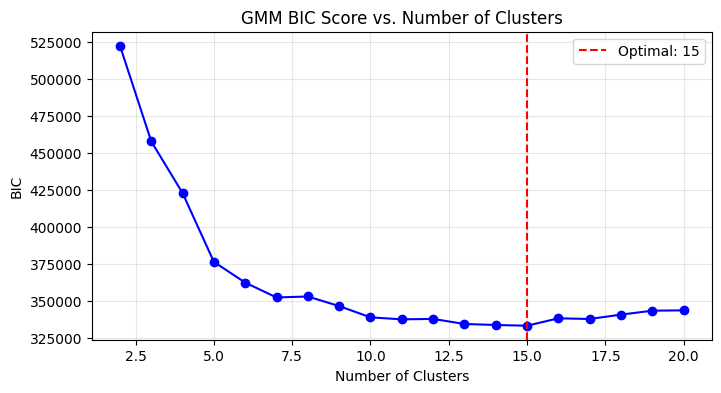

发现 15 个行为类别


In [44]:
# ==================== 使用示例 ====================
if __name__ == "__main__":
    # 假设已有数据:
# 调用主函数
    segments, model, scaler, inter = segment_behavior(ta_p, imu_a[:, 0:6])


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_behavior_segments(timestamps, imu_data, segments_df, save_path=None):
    """
    可视化: IMU 时间序列 + 行为片段着色
    """
    # 计算加速度模长作为参考
    acc_mag = np.sqrt(np.sum(imu_data[:, 0:3]**2, axis=1))
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True, 
                             gridspec_kw={'height_ratios': [2, 1]})
    
    # 上图: 加速度模长
    axes[0].plot(timestamps, acc_mag, color='gray', alpha=0.7, linewidth=0.5)
    axes[0].set_ylabel('Acceleration Magnitude (m/s²)')
    axes[0].set_title('IMU Data with Behavior Segments')
    
    # 为每个行为类别分配颜色
    unique_behaviors = segments_df['behavior_id'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_behaviors)))
    color_map = {bid: colors[i] for i, bid in enumerate(unique_behaviors)}
    
    # 在图上用半透明色块标注行为片段
    for _, row in segments_df.iterrows():
        bid = row['behavior_id']
        axes[0].axvspan(row['start_time'], row['end_time'], 
                       alpha=0.3, color=color_map[bid])
    
    # 下图: 行为标签时间轴
    for _, row in segments_df.iterrows():
        bid = row['behavior_id']
        axes[1].barh(0, row['end_time'] - row['start_time'], 
                    left=row['start_time'], height=0.8, 
                    color=color_map[bid], edgecolor='white')
    
    axes[1].set_yticks([0])
    axes[1].set_yticklabels(['Behavior'])
    axes[1].set_xlabel('Time (s)')
    axes[1].set_xlim(timestamps[0], timestamps[-1])
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[b], label=f'Behavior {b}') 
                      for b in unique_behaviors]
    axes[0].legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 使用
plot_behavior_segments(ta_p, imu_a[:, 0:6], segments, 'behavior_segments.png')

NameError: name 'segments' is not defined

KeyboardInterrupt: 

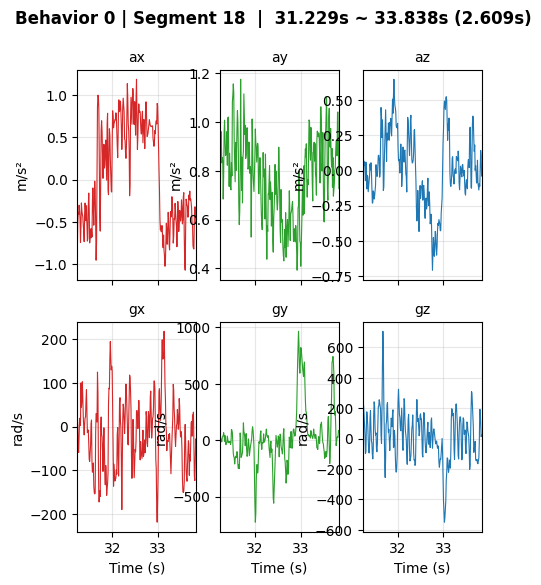

In [33]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_behavior_class_signals(
    timestamps: np.ndarray,
    imu_data: np.ndarray,
    segments_df: pd.DataFrame,
    output_dir: str = "behavior_signals",
    width_per_second: float = 2.0,
    min_width: float = 4.0,
    max_width: float = 24.0,
    row_height: float = 3.0
):
    """
    将每个行为类别的所有片段输出为信号图。
    每个片段一张图：第一行三轴加速度，第二行三轴角速度。
    图像水平宽度与片段长度成正比。
    
    参数:
        timestamps: (n,) 时间戳数组
        imu_data:   (n, 6) [ax, ay, az, gx, gy, gz]
        segments_df: 行为片段 DataFrame
        output_dir:  输出根目录
        width_per_second: 每1秒时长对应的图像宽度（英寸）
        min_width: 图像最小宽度（英寸）
        max_width: 图像最大宽度（英寸）
        row_height: 每行的高度（英寸）
    """
    acc_cols = ['ax', 'ay', 'az']
    gyro_cols = ['gx', 'gy', 'gz']
    acc_indices = [0, 1, 2]
    gyro_indices = [3, 4, 5]
    acc_colors = ['#d62728', '#2ca02c', '#1f77b4']  # 红, 绿, 蓝
    gyro_colors = ['#d62728', '#2ca02c', '#1f77b4']
    
    for behavior_id, group in segments_df.groupby('behavior_id'):
        class_dir = os.path.join(output_dir, f"behavior_{behavior_id}")
        os.makedirs(class_dir, exist_ok=True)
        
        for seg_idx, row in group.iterrows():
            start_t = row['start_time']
            end_t = row['end_time']
            duration = row['duration_sec']
            
            # 根据片段时长计算图像宽度，并限制在合理范围内
            fig_width = np.clip(duration * width_per_second, min_width, max_width)
            fig_height = row_height * 2  # 两行
            
            mask = (timestamps >= start_t) & (timestamps <= end_t)
            seg_time = timestamps[mask]
            seg_data = imu_data[mask]
            
            if len(seg_time) == 0:
                continue
            
            # 创建 2行3列 的 subplots
            fig, axes = plt.subplots(2, 3, figsize=(fig_width, fig_height), sharex='col')
            fig.suptitle(f'Behavior {behavior_id} | Segment {seg_idx}  |  '
                         f'{start_t:.3f}s ~ {end_t:.3f}s ({duration:.3f}s)',
                         fontsize=12, fontweight='bold')
            
            # ---------- 第一行: 三轴加速度 ----------
            for i, (ax_idx, col_name, color) in enumerate(zip(acc_indices, acc_cols, acc_colors)):
                ax = axes[0, i]
                ax.plot(seg_time, seg_data[:, ax_idx], color=color, linewidth=0.8)
                ax.set_title(col_name, fontsize=10)
                ax.set_ylabel('m/s²')
                ax.grid(True, alpha=0.3)
                ax.set_xlim(seg_time[0], seg_time[-1])
                ax.tick_params(labelbottom=False)  # 第一行不显示x轴刻度
            
            # ---------- 第二行: 三轴角速度 ----------
            for i, (gy_idx, col_name, color) in enumerate(zip(gyro_indices, gyro_cols, gyro_colors)):
                ax = axes[1, i]
                ax.plot(seg_time, seg_data[:, gy_idx], color=color, linewidth=0.8)
                ax.set_title(col_name, fontsize=10)
                ax.set_ylabel('rad/s')
                ax.set_xlabel('Time (s)')
                ax.grid(True, alpha=0.3)
                ax.set_xlim(seg_time[0], seg_time[-1])
            
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            
            save_path = os.path.join(class_dir, f"seg{seg_idx:04d}.png")
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close(fig)
        
        print(f"Behavior {behavior_id}: 已保存 {len(group)} 个片段到 {class_dir}/")

plot_behavior_class_signals(ta_p, imu_a[:, 0:6], segments, output_dir="F:/IMU_computational_ethology/Data/LSD/GRUPlot")

In [35]:
#保存视频
import cv2
import os
import pandas as pd
import numpy as np


def merge_adjacent_segments(segments_df: pd.DataFrame) -> pd.DataFrame:
    """
    合并相邻的相同行为类别片段。
    输入的 segments_df 可能已合并，但再做一次确保无遗漏。
    """
    if len(segments_df) == 0:
        return segments_df

    merged = []
    current = {
        'start_time': float(segments_df.iloc[0]['start_time']),
        'end_time': float(segments_df.iloc[0]['end_time']),
        'behavior_id': int(segments_df.iloc[0]['behavior_id'])
    }

    for i in range(1, len(segments_df)):
        row = segments_df.iloc[i]
        if int(row['behavior_id']) == current['behavior_id']:
            # 同类：延长当前片段的终止时间
            current['end_time'] = float(row['end_time'])
        else:
            # 异类：保存当前片段，开启新片段
            merged.append(current.copy())
            current = {
                'start_time': float(row['start_time']),
                'end_time': float(row['end_time']),
                'behavior_id': int(row['behavior_id'])
            }

    merged.append(current)
    return pd.DataFrame(merged)


def cut_video_by_behavior(
    video_path: str,
    imu_data: np.ndarray,
    timestamps: np.ndarray,
    segments_df: pd.DataFrame,
    output_dir: str,
    video_format: str = 'mp4'
):
    """
    按行为类别切割视频并保存到以聚类命名的子文件夹中。

    参数:
        video_path:   原始视频路径
        imu_data:     (n, 6) IMU数据，保留接口一致性，本函数不直接使用
        timestamps:   (n,) 时间戳数组，用于与视频帧对齐
        segments_df:  行为片段 DataFrame，需包含 start_time, end_time, behavior_id
        output_dir:   输出根目录
        video_format: 输出视频格式，默认 mp4
    """
    # 1. 合并相邻相同类别
    merged = merge_adjacent_segments(segments_df)
    print(f"合并后: {len(merged)} 个片段 (原始 {len(segments_df)} 个)")

    # 2. 打开视频
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"无法打开视频: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # 3. 时间对齐：视频第0帧对应 timestamps[0]
    time_offset = float(timestamps[0])

    # 4. 遍历每个片段，切割并保存
    for seg_idx, row in merged.iterrows():
        bid = int(row['behavior_id'])
        start_t = float(row['start_time'])
        end_t = float(row['end_time'])

        # 时间戳 → 帧索引
        start_frame = int((start_t - time_offset) * fps)
        end_frame = int((end_t - time_offset) * fps)

        # 边界裁剪
        start_frame = max(0, start_frame)
        end_frame = min(total_frames - 1, end_frame)

        if start_frame >= end_frame:
            print(f"  跳过过短片段: behavior_{bid} seg{seg_idx} ({start_frame}-{end_frame})")
            continue

        # 创建以聚类命名的子文件夹
        class_dir = os.path.join(output_dir, f"behavior_{bid}")
        os.makedirs(class_dir, exist_ok=True)

        # 构建输出视频路径
        ext = video_format.lower().replace('.', '')
        if ext == 'mp4':
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        elif ext == 'avi':
            fourcc = cv2.VideoWriter_fourcc(*'XVID')
        else:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        out_path = os.path.join(
            class_dir,
            f"seg{seg_idx:04d}_{start_t:.2f}s_{end_t:.2f}s.{ext}"
        )

        writer = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
        if not writer.isOpened():
            print(f"  警告: 无法创建视频写入器: {out_path}")
            continue

        # 定位到起始帧
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

        # 逐帧读取并写入
        n_written = 0
        for _ in range(start_frame, end_frame + 1):
            ret, frame = cap.read()
            if not ret or frame is None:
                break
            writer.write(frame)
            n_written += 1

        writer.release()
        print(f"  Saved: behavior_{bid}/seg{seg_idx:04d} ({n_written} frames, {n_written/fps:.2f}s)")

    cap.release()
    print("视频切割完成。")

In [36]:
cut_video_by_behavior(
    video_path="F:/IMU_computational_ethology/Data/LSD/LSD_data2_x264.mp4",
    imu_data=imu_a[:, 0:6],
    timestamps=ta_p,
    segments_df=segments,
    output_dir="F:/IMU_computational_ethology/Data/LSD/GRU_Clips"
)

合并后: 2264 个片段 (原始 2397 个)
  Saved: behavior_0/seg0000 (205 frames, 6.84s)
  Saved: behavior_6/seg0001 (103 frames, 3.44s)
  Saved: behavior_0/seg0002 (25 frames, 0.83s)
  Saved: behavior_6/seg0003 (18 frames, 0.60s)
  Saved: behavior_1/seg0004 (18 frames, 0.60s)
  Saved: behavior_0/seg0005 (37 frames, 1.23s)
  Saved: behavior_6/seg0006 (73 frames, 2.44s)
  Saved: behavior_0/seg0007 (37 frames, 1.23s)
  Saved: behavior_6/seg0008 (61 frames, 2.04s)
  Saved: behavior_0/seg0009 (121 frames, 4.04s)
  Saved: behavior_6/seg0010 (49 frames, 1.63s)
  Saved: behavior_0/seg0011 (176 frames, 5.87s)
  Saved: behavior_6/seg0012 (19 frames, 0.63s)
  Saved: behavior_0/seg0013 (79 frames, 2.64s)
  Saved: behavior_6/seg0014 (55 frames, 1.84s)
  Saved: behavior_0/seg0015 (43 frames, 1.43s)
  Saved: behavior_6/seg0016 (140 frames, 4.67s)
  Saved: behavior_0/seg0017 (61 frames, 2.04s)
  Saved: behavior_6/seg0018 (42 frames, 1.40s)
  Saved: behavior_0/seg0019 (67 frames, 2.24s)
  Saved: behavior_6/seg0020 (

KeyboardInterrupt: 

In [ ]:
# 假设已有
# video_path = "mouse_session.mp4"
# ta_p: (n,) 时间戳
# imu_a: (n, 6) IMU数据
# segments: 分割结果 DataFrame

cut_video_by_behavior(
    video_path="F:/IMU_computational_ethology/Data/2mouse_imu_83label/data2_batch.mp4",
    imu_data=imu_a[:, 0:6],
    timestamps=ta_p,
    segments_df=segments,
    output_dir="F:/IMU_computational_ethology/Data/2mouse_imu_83label/GRU_Clips"
)

In [ ]:
def plot_behavior_timeline(timestamps, imu_data, segments_df, save_path=None):
    """
    在IMU信号时间轴上叠加行为片段着色
    """
    # 计算加速度模长作为参考信号
    acc_mag = np.sqrt(np.sum(imu_data[:, 0:3]**2, axis=1))
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
    
    # 上图：加速度模长 + 行为片段着色
    axes[0].plot(timestamps, acc_mag, color='gray', alpha=0.5, linewidth=0.5, label='Acc Mag')
    axes[0].set_ylabel('Acceleration Magnitude (m/s²)')
    axes[0].set_title('Behavior Segmentation Timeline')
    
    # 为每个行为分配颜色
    unique_behaviors = sorted(segments_df['behavior_id'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(unique_behaviors))))
    color_map = {bid: colors[i] for i, bid in enumerate(unique_behaviors)}
    
    # 半透明色块标注行为片段
    for _, row in segments_df.iterrows():
        bid = row['behavior_id']
        axes[0].axvspan(row['start_time'], row['end_time'],
                       alpha=0.3, color=color_map[bid])
    
    # 添加图例
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[b], label=f'Behavior {b}') 
                      for b in unique_behaviors]
    axes[0].legend(handles=legend_elements, loc='upper right', ncol=3)
    
    # 下图：行为状态条带
    for _, row in segments_df.iterrows():
        bid = row['behavior_id']
        axes[1].barh(0, row['end_time'] - row['start_time'],
                    left=row['start_time'], height=0.8,
                    color=color_map[bid], edgecolor='white')
    
    axes[1].set_yticks([])
    axes[1].set_xlabel('Time (s)')
    axes[1].set_xlim(timestamps[0], timestamps[-1])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # 统计摘要
    print("\n行为片段统计:")
    total_time = segments_df['duration_sec'].sum()
    for bid in unique_behaviors:
        b = segments_df[segments_df['behavior_id'] == bid]
        ratio = b['duration_sec'].sum() / total_time
        print(f"  Behavior {bid}: {len(b)} 个片段, 总时长 {b['duration_sec'].sum():.1f}s ({ratio*100:.1f}%)")

# 使用
plot_behavior_timeline(ta_p, imu_a[:, 0:6], segments)

In [ ]:
import umap
import matplotlib.pyplot as plt

def visualize_latent_space(z, labels, timestamps=None, method='umap', save_path=None):
    """
    潜在空间可视化：观察聚类是否分离、时序是否连续
    """
    if method == 'umap':
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    else:
        from sklearn.manifold import TSNE
        reducer = TSNE(n_components=2, perplexity=30, random_state=42)
    
    z_2d = reducer.fit_transform(z)
    
    fig, axes = plt.subplots(1, 2 if timestamps is not None else 1, 
                            figsize=(14 if timestamps is not None else 7, 6))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    # 左图：按聚类标签着色
    scatter = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], 
                             c=labels, cmap='tab10', s=5, alpha=0.6)
    axes[0].set_title('Latent Space (Colored by Cluster)')
    axes[0].set_xlabel('Dim 1')
    axes[0].set_ylabel('Dim 2')
    plt.colorbar(scatter, ax=axes[0], label='Behavior ID')
    
    # 右图：按时间着色（验证时序连续性）
    if timestamps is not None:
        # 使用窗口中心时间
        scatter2 = axes[1].scatter(z_2d[:, 0], z_2d[:, 1], 
                                  c=timestamps, cmap='viridis', s=5, alpha=0.6)
        axes[1].set_title('Latent Space (Colored by Time)')
        axes[1].set_xlabel('Dim 1')
        axes[1].set_ylabel('Dim 2')
        plt.colorbar(scatter2, ax=axes[1], label='Time (s)')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # 判断标准
    print("\n可视化判断:")
    print("  - 同类标签是否形成紧密团块?")
    print("  - 不同类之间是否有清晰边界?")
    print("  - 时间着色是否呈现连续轨迹（而非混乱散点）?")

# 使用
visualize_latent_space(z, labels, win_center_times)